# Cine 时间频谱分析

这个 notebook 用来做一件很具体的事：

- 加载一段 Phantom `.cine` 视频
- 沿着第 0 个维度，也就是时间 / frame 维度，对每个像素做傅里叶变换
- 看全局主频、每个像素的主频、每个像素的频响强度
- 基于这些结果，判断应该优先尝试什么预处理

这里默认 `video.shape == (frame, height, width)`。

In [250]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
if not (repo_root / "OSCC_postprocessing").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(repo_root)

C:\Users\Jiang\Documents\Mie_Postprocessing_Py


## 配置

先把 `CINE_PATH` 改成你的文件路径。`FPS` 要填视频真实帧率，这会直接影响频率轴。

In [251]:
CINE_PATH = Path(r"F:\\G\\Annoyance\\T78_Schlieren Cam_10.cine")
CONFIG_PATH = None  # None -> use CINE_PATH.with_name("config.json")

FRAME_LIMIT = None
FPS = 25_000.0

APPLY_CONFIG_ALIGNMENT = True
VIDEO_STRIP_RELATIVE_HEIGHT = 1.0  # align the full strip first, then compare top/middle/bottom thirds manually
INTERPOLATION = "nearest"
BORDER_MODE = "constant"

# Optional crop applied after alignment. Keep full strip first.
ROW_SLICE = slice(None)
COL_SLICE = slice(None)

# FFT analysis parameters
REMOVE_TEMPORAL_MEAN = True
APPLY_HANN_WINDOW = True
CHUNK_PIXELS = 16_384

# Low-frequency definition used to detect drift / slow fluctuations
LOW_FREQ_CUTOFF_HZ = 500.0

# Preview filter parameters
PREVIEW_LOW_PASS_HZ = 6000.0
LOW_PASS_FILTER_ORDER = 4
PREVIEW_HIGH_PASS_HZ = 8000.0
HIGH_PASS_FILTER_ORDER = 4
PREVIEW_FILTER_MODE = "bandstop"  # one of: lowpass, highpass, bandpass, bandstop

# Visualization parameters
TOP_PIXEL_PERCENTILE = 99.5
TOP_PIXEL_COUNT = 6
MAX_PLOT_FREQ_HZ = 5_000.0
LOW_FREQ_VIEW_HZ = 500.0
LOW_FREQ_PEAK_COUNT = 8

assert CINE_PATH.exists(), f"File not found: {CINE_PATH}"
if CONFIG_PATH is None:
    CONFIG_PATH = CINE_PATH.with_name("config.json")
if APPLY_CONFIG_ALIGNMENT:
    assert CONFIG_PATH.exists(), f"Config not found: {CONFIG_PATH}"


In [252]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.fft import rfft, irfft, rfftfreq
from scipy.signal import butter, sosfiltfilt

from OSCC_postprocessing.cine.functions_videos import load_cine_video
from OSCC_postprocessing.rotation.rotate_with_alignment_cpu import rotate_video_nozzle_at_0_half_numpy

try:
    import cupy as cp
    from OSCC_postprocessing.rotation.rotate_with_alignment import rotate_video_nozzle_at_0_half_cupy
except Exception:
    cp = None
    rotate_video_nozzle_at_0_half_cupy = None

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["image.cmap"] = "gray"


## 加载视频

Video Info - Width: 768, Height: 768, Frames: 201
raw video shape: (201, 768, 768)
config: F:\G\Annoyance\config.json
centre: (180.0, 92.0)
offset: -45.000 deg
aligned strip shape: (201, 711, 711)
spray origin: (0, 355)
duration: 0.008040 s
frequency resolution: 124.378 Hz
nyquist: 12500.0 Hz


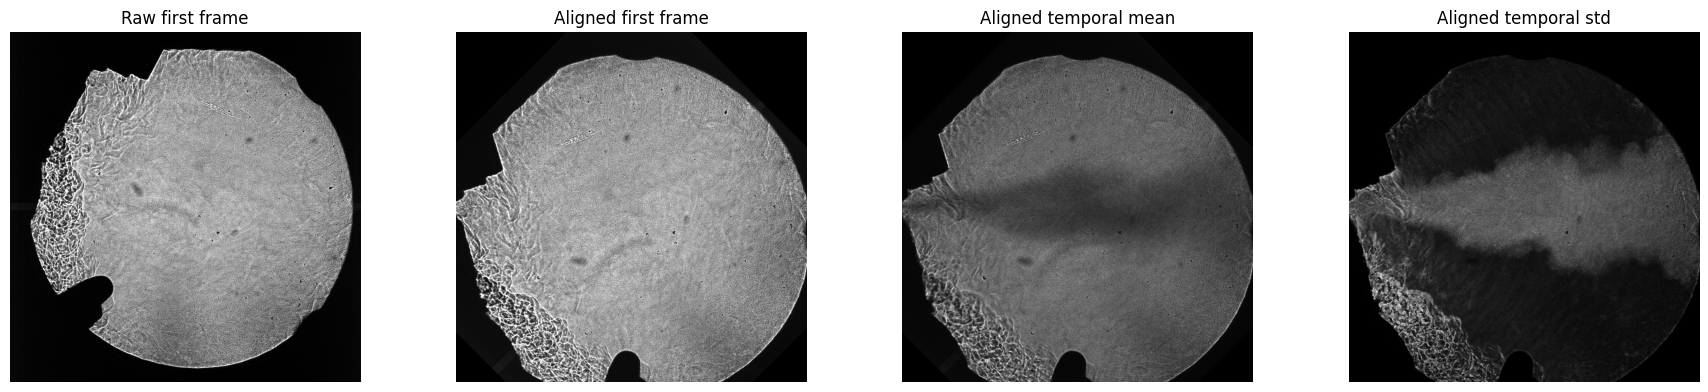

In [253]:
def load_processing_config(config_path):
    config_path = Path(config_path)
    with config_path.open("r", encoding="utf-8") as f:
        cfg = json.load(f)

    required_fields = [
        "plumes",
        "offset",
        "centre_x",
        "centre_y",
        "inner_radius",
        "outer_radius",
    ]
    missing = [field for field in required_fields if field not in cfg]
    if missing:
        raise KeyError(f"config.json missing required fields {missing}: {config_path}")
    return cfg


def build_aligned_strip(video, cfg, relative_height=1.0 / 3.0, interpolation="nearest", border_mode="constant"):
    centre = (float(cfg["centre_x"]), float(cfg["centre_y"]))
    offset = float(cfg["offset"])
    outer_radius = float(cfg["outer_radius"])

    out_h = max(1, int(round(float(relative_height) * outer_radius)))
    out_w = max(1, int(round(outer_radius)))
    out_shape = (out_h, out_w)

    use_gpu_rot = rotate_video_nozzle_at_0_half_cupy is not None and cp is not None
    if use_gpu_rot:
        try:
            video_backend = cp.asarray(video, dtype=cp.float32)
            segment, _, _ = rotate_video_nozzle_at_0_half_cupy(
                video_backend,
                centre,
                offset,
                interpolation=interpolation,
                border_mode=border_mode,
                out_shape=out_shape,
                cval=0.0,
                stack=True,
            )
            segment = cp.asnumpy(segment)
        except Exception as exc:
            print(f"GPU rotation failed ({exc}), falling back to CPU.")
            use_gpu_rot = False

    if not use_gpu_rot:
        segment, _, _ = rotate_video_nozzle_at_0_half_numpy(
            np.asarray(video, dtype=np.float32),
            centre,
            offset,
            interpolation=interpolation,
            border_mode=border_mode,
            out_shape=out_shape,
            cval=0.0,
            stack=True,
        )

    spray_origin = (0, out_shape[0] // 2)
    metadata = {
        "centre": centre,
        "offset": offset,
        "inner_radius": float(cfg["inner_radius"]),
        "outer_radius": outer_radius,
        "plumes": int(cfg["plumes"]),
        "out_shape": out_shape,
    }
    return np.asarray(segment, dtype=np.float32), spray_origin, metadata


raw_video = load_cine_video(str(CINE_PATH), frame_limit=FRAME_LIMIT).astype(np.float32, copy=False)
config = load_processing_config(CONFIG_PATH) if APPLY_CONFIG_ALIGNMENT else None

if APPLY_CONFIG_ALIGNMENT:
    video, spray_origin, strip_metadata = build_aligned_strip(
        raw_video,
        config,
        relative_height=VIDEO_STRIP_RELATIVE_HEIGHT,
        interpolation=INTERPOLATION,
        border_mode=BORDER_MODE,
    )
else:
    video = raw_video
    spray_origin = None
    strip_metadata = None

video = video[:, ROW_SLICE, COL_SLICE].astype(np.float32, copy=False)

n_frames, height, width = video.shape
duration_s = n_frames / FPS
freq_resolution_hz = FPS / n_frames

print(f"raw video shape: {raw_video.shape}")
if APPLY_CONFIG_ALIGNMENT:
    print(f"config: {CONFIG_PATH}")
    print(f"centre: {strip_metadata['centre']}")
    print(f"offset: {strip_metadata['offset']:.3f} deg")
    print(f"aligned strip shape: {video.shape}")
    print(f"spray origin: {spray_origin}")
else:
    print(f"video shape: {video.shape}")
print(f"duration: {duration_s:.6f} s")
print(f"frequency resolution: {freq_resolution_hz:.3f} Hz")
print(f"nyquist: {FPS / 2:.1f} Hz")

raw_frame0 = raw_video[0]
frame0 = video[0]
mean_frame = video.mean(axis=0)
std_frame = video.std(axis=0)

if APPLY_CONFIG_ALIGNMENT:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    axes[0].imshow(raw_frame0, vmin=np.percentile(raw_frame0, 1), vmax=np.percentile(raw_frame0, 99))
    axes[0].set_title("Raw first frame")
    axes[1].imshow(frame0, vmin=np.percentile(frame0, 1), vmax=np.percentile(frame0, 99))
    axes[1].set_title("Aligned first frame")
    axes[2].imshow(mean_frame)
    axes[2].set_title("Aligned temporal mean")
    axes[3].imshow(std_frame)
    axes[3].set_title("Aligned temporal std")
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(frame0, vmin=np.percentile(frame0, 1), vmax=np.percentile(frame0, 99))
    axes[0].set_title("First frame")
    axes[1].imshow(mean_frame)
    axes[1].set_title("Temporal mean")
    axes[2].imshow(std_frame)
    axes[2].set_title("Temporal std")

for ax in axes:
    ax.set_axis_off()
plt.tight_layout()
plt.show()


## 工具函数

这里按像素块分批做时间 FFT，避免一次性把整段视频的全频谱都放进内存。

In [254]:
def analyze_temporal_fft(
    video,
    fps,
    chunk_pixels=16_384,
    remove_temporal_mean=True,
    apply_hann_window=True,
    low_freq_cutoff_hz=500.0,
):
    n_frames, height, width = video.shape
    pixel_count = height * width
    video_2d = video.reshape(n_frames, pixel_count)

    freqs = rfftfreq(n_frames, d=1.0 / fps)
    non_dc_mask = freqs > 0
    low_mask = (freqs > 0) & (freqs <= low_freq_cutoff_hz)
    window = np.hanning(n_frames).astype(np.float32) if apply_hann_window else np.ones(n_frames, dtype=np.float32)

    mean_power_sum = np.zeros(freqs.shape, dtype=np.float64)
    dominant_idx = np.zeros(pixel_count, dtype=np.int32)
    dominant_power = np.zeros(pixel_count, dtype=np.float32)
    low_ratio = np.zeros(pixel_count, dtype=np.float32)

    for start in range(0, pixel_count, chunk_pixels):
        stop = min(start + chunk_pixels, pixel_count)
        block = video_2d[:, start:stop].astype(np.float32, copy=True)

        if remove_temporal_mean:
            block -= block.mean(axis=0, keepdims=True)

        block *= window[:, None]
        spectrum = rfft(block, axis=0, workers=-1)
        power = np.abs(spectrum) ** 2

        mean_power_sum += power.sum(axis=1)

        power_no_dc = power[1:]
        local_idx = power_no_dc.argmax(axis=0) + 1
        dominant_idx[start:stop] = local_idx
        dominant_power[start:stop] = power[local_idx, np.arange(stop - start)].astype(np.float32)

        total_non_dc = power[non_dc_mask].sum(axis=0)
        low_band = power[low_mask].sum(axis=0)
        low_ratio[start:stop] = np.divide(
            low_band,
            total_non_dc,
            out=np.zeros(stop - start, dtype=np.float32),
            where=total_non_dc > 0,
        )

    mean_power = mean_power_sum / pixel_count

    return {
        "freqs": freqs,
        "mean_power": mean_power,
        "dominant_freq_map": freqs[dominant_idx].reshape(height, width),
        "dominant_power_map": dominant_power.reshape(height, width),
        "low_ratio_map": low_ratio.reshape(height, width),
    }


def pixel_power_spectrum(trace, fps, remove_temporal_mean=True, apply_hann_window=True):
    trace = np.asarray(trace, dtype=np.float32).copy()
    if remove_temporal_mean:
        trace -= trace.mean()
    if apply_hann_window:
        trace *= np.hanning(trace.shape[0]).astype(np.float32)
    spectrum = rfft(trace, workers=-1)
    power = np.abs(spectrum) ** 2
    freqs = rfftfreq(trace.shape[0], d=1.0 / fps)
    return freqs, power


def fft_temporal_filter(video, fps, pass_mask, chunk_pixels=16_384):
    n_frames, height, width = video.shape
    pixel_count = height * width
    video_2d = video.reshape(n_frames, pixel_count)
    filtered = np.empty_like(video, dtype=np.float32)
    filtered_2d = filtered.reshape(n_frames, pixel_count)

    for start in range(0, pixel_count, chunk_pixels):
        stop = min(start + chunk_pixels, pixel_count)
        block = video_2d[:, start:stop].astype(np.float32, copy=True)
        spectrum = rfft(block, axis=0, workers=-1)
        spectrum *= pass_mask[:, None]
        filtered_2d[:, start:stop] = irfft(spectrum, n=n_frames, axis=0, workers=-1).astype(np.float32)

    return filtered


def _temporal_butterworth_filter(video, fps, critical_hz, btype, order=2, chunk_pixels=16_384):
    if video.ndim != 3:
        raise ValueError("video must have shape (frames, height, width)")

    n_frames, height, width = video.shape
    pixel_count = height * width
    nyquist_hz = 0.5 * fps

    if btype in {"lowpass", "highpass"}:
        cutoff_hz = float(critical_hz)
        if not (0 < cutoff_hz < nyquist_hz):
            raise ValueError(f"cutoff_hz must be between 0 and {nyquist_hz:.3f} Hz")
    elif btype in {"bandpass", "bandstop"}:
        if len(critical_hz) != 2:
            raise ValueError("critical_hz must be a 2-tuple for band-pass / band-stop")
        low_hz, high_hz = float(critical_hz[0]), float(critical_hz[1])
        if not (0 < low_hz < high_hz < nyquist_hz):
            raise ValueError(
                f"band edges must satisfy 0 < low < high < {nyquist_hz:.3f} Hz, got {(low_hz, high_hz)}"
            )
    else:
        raise ValueError(f"Unsupported btype: {btype}")

    sos = butter(order, critical_hz, btype=btype, fs=fps, output="sos")
    default_padlen = 3 * (2 * len(sos) + 1)
    padlen = min(default_padlen, max(0, n_frames - 2))

    video_2d = video.reshape(n_frames, pixel_count)
    filtered = np.empty_like(video, dtype=np.float32)
    filtered_2d = filtered.reshape(n_frames, pixel_count)

    for start in range(0, pixel_count, chunk_pixels):
        stop = min(start + chunk_pixels, pixel_count)
        block = video_2d[:, start:stop].astype(np.float32, copy=True)
        filtered_block = sosfiltfilt(sos, block, axis=0, padtype="odd", padlen=padlen)
        filtered_2d[:, start:stop] = filtered_block.astype(np.float32, copy=False)

    return filtered


def temporal_high_pass_butterworth(video, fps, cutoff_hz=300.0, order=2, chunk_pixels=16_384):
    return _temporal_butterworth_filter(
        video,
        fps,
        critical_hz=cutoff_hz,
        btype="highpass",
        order=order,
        chunk_pixels=chunk_pixels,
    )


def temporal_low_pass_butterworth(video, fps, cutoff_hz=300.0, order=2, chunk_pixels=16_384):
    return _temporal_butterworth_filter(
        video,
        fps,
        critical_hz=cutoff_hz,
        btype="lowpass",
        order=order,
        chunk_pixels=chunk_pixels,
    )


def temporal_band_pass_butterworth(video, fps, low_cut_hz, high_cut_hz, order=2, chunk_pixels=16_384):
    return _temporal_butterworth_filter(
        video,
        fps,
        critical_hz=(low_cut_hz, high_cut_hz),
        btype="bandpass",
        order=order,
        chunk_pixels=chunk_pixels,
    )


def temporal_band_stop_butterworth(video, fps, low_cut_hz, high_cut_hz, order=2, chunk_pixels=16_384):
    return _temporal_butterworth_filter(
        video,
        fps,
        critical_hz=(low_cut_hz, high_cut_hz),
        btype="bandstop",
        order=order,
        chunk_pixels=chunk_pixels,
    )


def region_reference_trace(region_video, reducer="median"):
    if reducer == "median":
        trace = np.median(region_video, axis=(1, 2))
    elif reducer == "mean":
        trace = np.mean(region_video, axis=(1, 2))
    else:
        raise ValueError(f"Unsupported reducer: {reducer}")
    return np.asarray(trace, dtype=np.float32)


def per_pixel_regression_subtract(region_video, reference_trace, chunk_pixels=16_384):
    n_frames, height, width = region_video.shape
    pixel_count = height * width
    reference_trace = np.asarray(reference_trace, dtype=np.float32).reshape(n_frames)
    ref_centered = reference_trace - reference_trace.mean()
    ref_energy = float(np.dot(ref_centered, ref_centered))
    if ref_energy <= np.finfo(np.float32).eps:
        return np.asarray(region_video, dtype=np.float32).copy()

    region_2d = region_video.reshape(n_frames, pixel_count)
    corrected = np.empty_like(region_video, dtype=np.float32)
    corrected_2d = corrected.reshape(n_frames, pixel_count)

    for start in range(0, pixel_count, chunk_pixels):
        stop = min(start + chunk_pixels, pixel_count)
        block = region_2d[:, start:stop].astype(np.float32, copy=True)
        block_mean = block.mean(axis=0, keepdims=True)
        block_centered = block - block_mean
        beta = (ref_centered @ block_centered) / ref_energy
        corrected_2d[:, start:stop] = (
            block_centered - ref_centered[:, None] * beta[None, :] + block_mean
        ).astype(np.float32, copy=False)

    return corrected


def _smooth_1d(signal_1d, window_bins=9):
    signal_1d = np.asarray(signal_1d)
    window_bins = int(window_bins)
    if window_bins <= 1:
        return signal_1d
    kernel = np.ones(window_bins, dtype=np.float32)
    kernel /= kernel.sum()
    if np.iscomplexobj(signal_1d):
        real = np.convolve(np.real(signal_1d), kernel, mode="same")
        imag = np.convolve(np.imag(signal_1d), kernel, mode="same")
        return real + 1j * imag
    return np.convolve(signal_1d, kernel, mode="same")


def frequency_dependent_reference_subtract(
    region_video,
    reference_trace,
    chunk_pixels=16_384,
    smooth_bins=9,
    eps=1e-8,
):
    n_frames, height, width = region_video.shape
    pixel_count = height * width
    reference_trace = np.asarray(reference_trace, dtype=np.float32).reshape(n_frames)
    ref_centered = reference_trace - reference_trace.mean()
    R = rfft(ref_centered, workers=-1)
    ref_power = np.abs(R) ** 2
    smooth_ref_power = _smooth_1d(ref_power, window_bins=smooth_bins) + eps

    region_2d = region_video.reshape(n_frames, pixel_count)
    cross_sum = np.zeros(R.shape, dtype=np.complex64)
    for start in range(0, pixel_count, chunk_pixels):
        stop = min(start + chunk_pixels, pixel_count)
        block = region_2d[:, start:stop].astype(np.float32, copy=True)
        block_centered = block - block.mean(axis=0, keepdims=True)
        X = rfft(block_centered, axis=0, workers=-1)
        cross_sum += np.sum(X * np.conj(R)[:, None], axis=1)

    cross_mean = cross_sum / max(pixel_count, 1)
    gain = _smooth_1d(cross_mean, window_bins=smooth_bins) / smooth_ref_power

    corrected = np.empty_like(region_video, dtype=np.float32)
    corrected_2d = corrected.reshape(n_frames, pixel_count)
    for start in range(0, pixel_count, chunk_pixels):
        stop = min(start + chunk_pixels, pixel_count)
        block = region_2d[:, start:stop].astype(np.float32, copy=True)
        block_mean = block.mean(axis=0, keepdims=True)
        block_centered = block - block_mean
        X = rfft(block_centered, axis=0, workers=-1)
        X_clean = X - gain[:, None] * R[:, None]
        corrected_2d[:, start:stop] = (
            irfft(X_clean, n=n_frames, axis=0, workers=-1) + block_mean
        ).astype(np.float32, copy=False)

    return corrected, gain


## 计算每像素时间频谱

In [255]:
analysis = analyze_temporal_fft(
    video,
    fps=FPS,
    chunk_pixels=CHUNK_PIXELS,
    remove_temporal_mean=REMOVE_TEMPORAL_MEAN,
    apply_hann_window=APPLY_HANN_WINDOW,
    low_freq_cutoff_hz=LOW_FREQ_CUTOFF_HZ,
)

freqs = analysis["freqs"]
mean_power = analysis["mean_power"]
dominant_freq_map = analysis["dominant_freq_map"]
dominant_power_map = analysis["dominant_power_map"]
low_ratio_map = analysis["low_ratio_map"]

strong_threshold = np.percentile(dominant_power_map, TOP_PIXEL_PERCENTILE)
strong_mask = dominant_power_map >= strong_threshold

print(f"strong pixel threshold (p{TOP_PIXEL_PERCENTILE}): {strong_threshold:.3e}")
print(f"strong pixel fraction: {strong_mask.mean() * 100:.3f}%")

strong pixel threshold (p99.5): 3.944e+09
strong pixel fraction: 0.500%


## 全局平均频谱

这里是所有像素功率谱的平均值。它能快速看出整段视频有没有明显的低频漂移，或者某个窄带频率峰值。

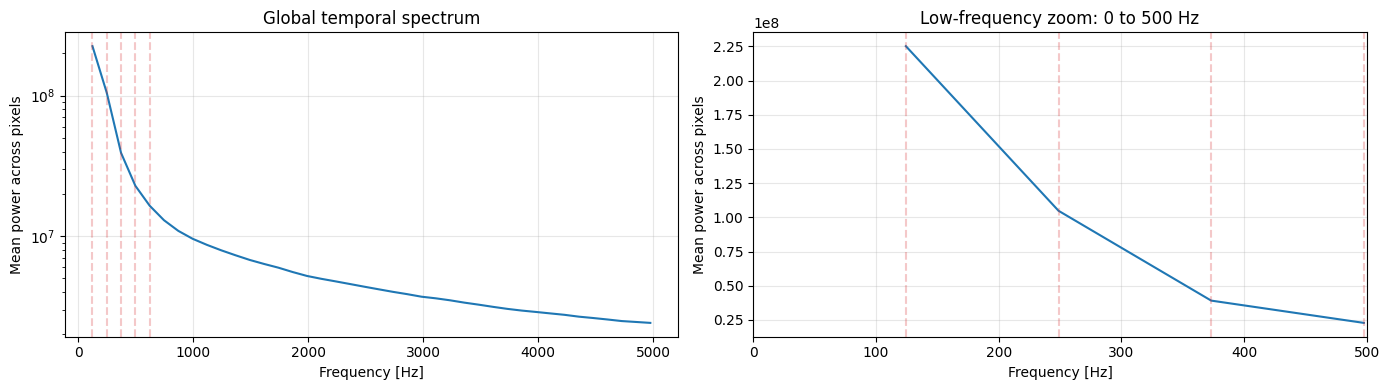

Top global peaks:
     124.38 Hz | power = 2.252e+08
     248.76 Hz | power = 1.048e+08
     373.13 Hz | power = 3.910e+07
     497.51 Hz | power = 2.281e+07
     621.89 Hz | power = 1.646e+07
     746.27 Hz | power = 1.298e+07
     870.65 Hz | power = 1.090e+07
     995.02 Hz | power = 9.574e+06

Top peaks in 0 to 500 Hz:
     124.38 Hz | power = 2.252e+08
     248.76 Hz | power = 1.048e+08
     373.13 Hz | power = 3.910e+07
     497.51 Hz | power = 2.281e+07


In [256]:
plot_mask = (freqs > 0) & (freqs <= MAX_PLOT_FREQ_HZ)
low_freq_view_mask = (freqs > 0) & (freqs <= LOW_FREQ_VIEW_HZ)

peak_indices = np.argsort(mean_power[1:])[::-1][:8] + 1
low_freq_indices = np.flatnonzero(low_freq_view_mask)
low_freq_peak_indices = low_freq_indices[np.argsort(mean_power[low_freq_indices])[::-1][:LOW_FREQ_PEAK_COUNT]]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(freqs[plot_mask], mean_power[plot_mask], lw=1.5)
axes[0].set_yscale("log")
axes[0].set_xlabel("Frequency [Hz]")
axes[0].set_ylabel("Mean power across pixels")
axes[0].set_title("Global temporal spectrum")
axes[0].grid(True, alpha=0.3)

for idx in peak_indices[:5]:
    if freqs[idx] <= MAX_PLOT_FREQ_HZ:
        axes[0].axvline(freqs[idx], color="tab:red", ls="--", alpha=0.25)

axes[1].plot(freqs[low_freq_view_mask], mean_power[low_freq_view_mask], lw=1.5)
axes[1].set_xlim(0, LOW_FREQ_VIEW_HZ)
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("Mean power across pixels")
axes[1].set_title(f"Low-frequency zoom: 0 to {LOW_FREQ_VIEW_HZ:.0f} Hz")
axes[1].grid(True, alpha=0.3)

for idx in low_freq_peak_indices:
    axes[1].axvline(freqs[idx], color="tab:red", ls="--", alpha=0.25)

plt.tight_layout()
plt.show()

print("Top global peaks:")
for idx in peak_indices:
    print(f"  {freqs[idx]:9.2f} Hz | power = {mean_power[idx]:.3e}")

print(f"\nTop peaks in 0 to {LOW_FREQ_VIEW_HZ:.0f} Hz:")
for idx in low_freq_peak_indices:
    print(f"  {freqs[idx]:9.2f} Hz | power = {mean_power[idx]:.3e}")

## ä¸Šä¸­ä¸‹ä¸‰å—çš„é¢‘è°±å¯¹æ¯”

è¿™é‡Œå…ˆæŠŠå¯¹é½åŽçš„ strip åœ¨é«˜åº¦æ–¹å‘ç­‰åˆ†æˆä¸Šã€ä¸­ã€ä¸‹ä¸‰å—ï¼Œå†æ¯”è¾ƒå®ƒä»¬å„è‡ªçš„å¹³å‡æ—¶é—´é¢‘è°±ã€‚è¿™æ ·å¯ä»¥å…ˆåˆ¤æ–­å–·é›¾ä¸Šæ²¿ã€ä¸­è½´å’Œä¸‹æ²¿é™„è¿‘æ˜¯ä¸æ˜¯æœ‰ä¸åŒçš„é¢‘çŽ‡ç»“æž„ã€‚

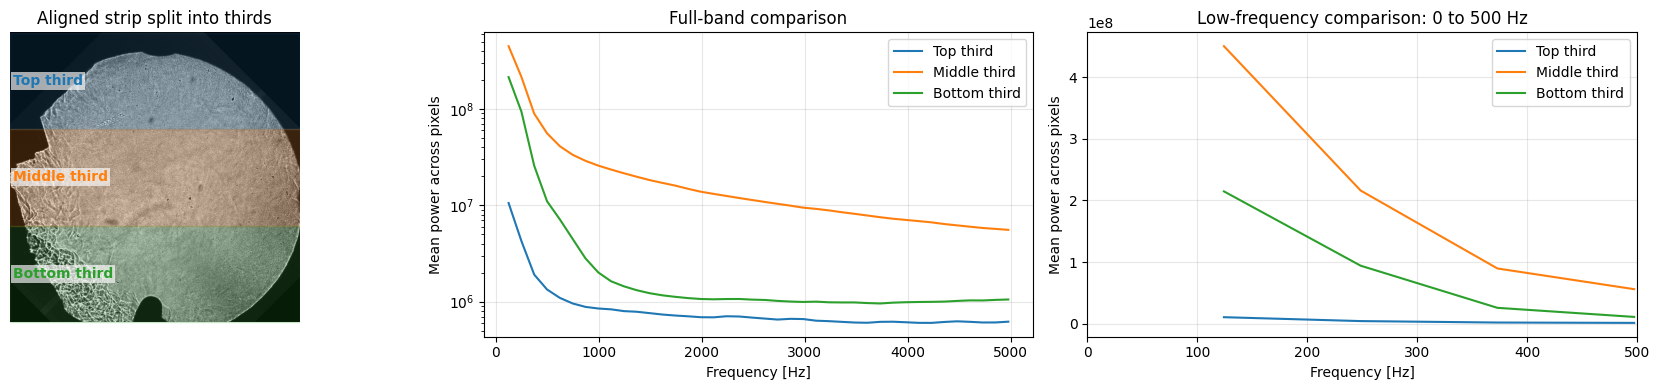

Dominant peaks by height band:
  Top third    rows [   0,  237) | global peak =   124.38 Hz | power = 1.057e+07 | low-band peak =   124.38 Hz | power = 1.057e+07
  Middle third rows [ 237,  474) | global peak =   124.38 Hz | power = 4.503e+08 | low-band peak =   124.38 Hz | power = 4.503e+08
  Bottom third rows [ 474,  711) | global peak =   124.38 Hz | power = 2.147e+08 | low-band peak =   124.38 Hz | power = 2.147e+08


In [257]:
band_labels = ("Top third", "Middle third", "Bottom third")
band_colors = ("tab:blue", "tab:orange", "tab:green")
row_edges = np.linspace(0, height, 4, dtype=int)

height_band_analyses = []
for label, color, start, stop in zip(band_labels, band_colors, row_edges[:-1], row_edges[1:]):
    band_video = video[:, start:stop, :]
    band_analysis = analyze_temporal_fft(
        band_video,
        fps=FPS,
        chunk_pixels=CHUNK_PIXELS,
        remove_temporal_mean=REMOVE_TEMPORAL_MEAN,
        apply_hann_window=APPLY_HANN_WINDOW,
        low_freq_cutoff_hz=LOW_FREQ_CUTOFF_HZ,
    )
    band_mean_power = band_analysis["mean_power"]
    top_idx = np.argmax(band_mean_power[1:]) + 1
    low_idx = np.flatnonzero((freqs > 0) & (freqs <= LOW_FREQ_VIEW_HZ))
    low_top_idx = low_idx[np.argmax(band_mean_power[low_idx])] if low_idx.size else None
    height_band_analyses.append(
        {
            "label": label,
            "color": color,
            "row_start": int(start),
            "row_stop": int(stop),
            "mean_power": band_mean_power,
            "top_idx": int(top_idx),
            "low_top_idx": None if low_top_idx is None else int(low_top_idx),
        }
    )

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].imshow(frame0, vmin=np.percentile(frame0, 1), vmax=np.percentile(frame0, 99))
for band in height_band_analyses:
    axes[0].axhspan(band["row_start"], band["row_stop"], color=band["color"], alpha=0.18)
    axes[0].text(
        6,
        0.5 * (band["row_start"] + band["row_stop"]),
        band["label"],
        color=band["color"],
        fontsize=10,
        fontweight="bold",
        va="center",
        ha="left",
        bbox=dict(facecolor="white", alpha=0.65, edgecolor="none", pad=1.5),
    )
axes[0].set_title("Aligned strip split into thirds")
axes[0].set_axis_off()

for band in height_band_analyses:
    axes[1].plot(freqs[plot_mask], band["mean_power"][plot_mask], lw=1.5, color=band["color"], label=band["label"])
axes[1].set_yscale("log")
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("Mean power across pixels")
axes[1].set_title("Full-band comparison")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

for band in height_band_analyses:
    axes[2].plot(
        freqs[low_freq_view_mask],
        band["mean_power"][low_freq_view_mask],
        lw=1.5,
        color=band["color"],
        label=band["label"],
    )
axes[2].set_xlim(0, LOW_FREQ_VIEW_HZ)
axes[2].set_xlabel("Frequency [Hz]")
axes[2].set_ylabel("Mean power across pixels")
axes[2].set_title(f"Low-frequency comparison: 0 to {LOW_FREQ_VIEW_HZ:.0f} Hz")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

print("Dominant peaks by height band:")
for band in height_band_analyses:
    top_freq = freqs[band["top_idx"]]
    top_power = band["mean_power"][band["top_idx"]]
    if band["low_top_idx"] is None:
        low_summary = "no low-frequency bins"
    else:
        low_freq = freqs[band["low_top_idx"]]
        low_power = band["mean_power"][band["low_top_idx"]]
        low_summary = f"low-band peak = {low_freq:8.2f} Hz | power = {low_power:.3e}"
    print(
        f"  {band['label']:12s} rows [{band['row_start']:4d}, {band['row_stop']:4d}) | "
        f"global peak = {top_freq:8.2f} Hz | power = {top_power:.3e} | {low_summary}"
    )


## ç”¨ Top third åšå‚è€ƒï¼Œæ¶ˆæŽ‰ Middle third çš„å…¬å…±åˆ†é‡

è¿™é‡Œå›ºå®šç”¨ `Top third` çš„ median trace ä½œä¸ºå‚è€ƒä¿¡å·ï¼Œç„¶åŽå¯¹ `Middle third` åšä¸¤ç§ç‰ˆæœ¬ï¼š

- `per-pixel regression subtraction`ï¼šæ—¶åŸŸé‡Œç»™æ¯ä¸ªåƒç´ æ‹Ÿåˆä¸€ä¸ªæ ‡é‡ç³»æ•°ï¼Œå†æ‰£æŽ‰å’Œå‚è€ƒåŒæ­¥çš„å…¬å…±æ³¢åŠ¨
- `frequency-dependent subtraction`ï¼šé¢‘åŸŸé‡Œå…ˆä¼°è®¡ middle third å¯¹ top reference çš„å¹³å‡å¤æ•°å¢žç›Šï¼Œå†æŒ‰é¢‘çŽ‡æ‰£æŽ‰å…¬å…±åˆ†é‡

å¦‚æžœè¿™ä¸¤ç§å¤„ç†åŽé¬¼å½±ã€é—ªçƒã€ä½Žé¢‘å…¬å…±èµ·ä¼æ˜Žæ˜¾ä¸‹é™ï¼Œå°±è¯´æ˜Žå¹²æ‰°æ›´åƒæ˜¯å…¨å±€äº®åº¦/æ›å…‰å…¬å…±æ¨¡æ€�ï¼Œè€Œä¸æ˜¯ä¸€ä¸ªçª„å¸¦ notch å°±èƒ½è§£å†³çš„é—®é¢˜ã€‚

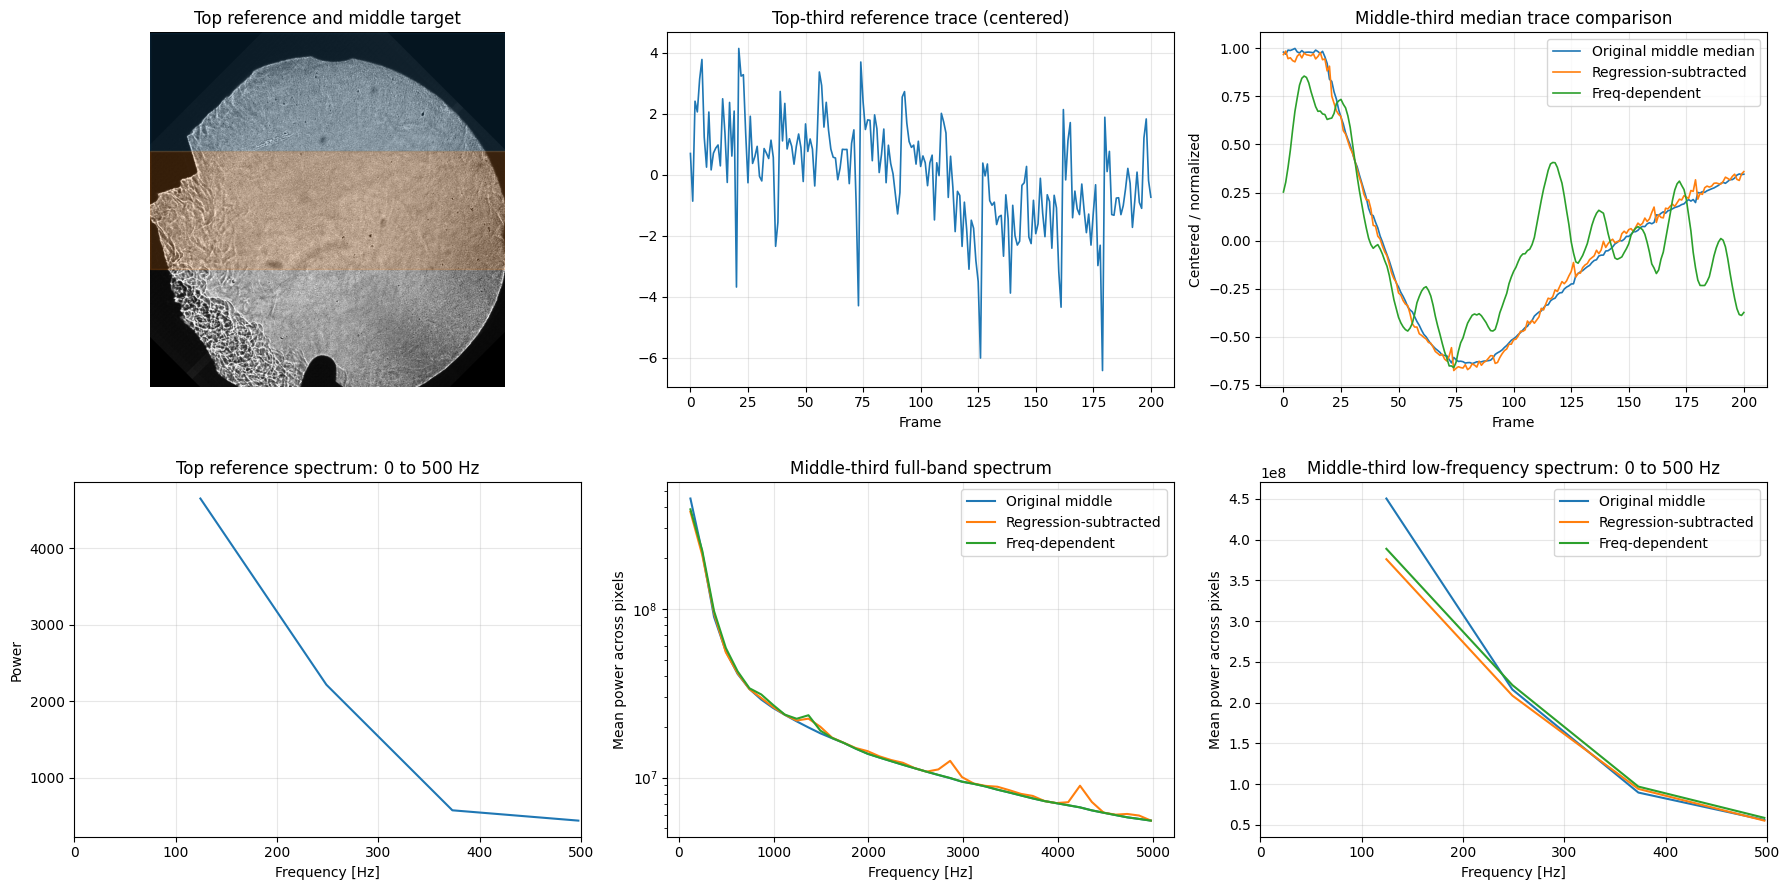

Top reference reducer: mean
Middle-third mean temporal std: original = 4.341e+02
  regression-subtracted = 4.252e+02 (+2.05% vs original)
  freq-dependent       = 4.332e+02 (+0.20% vs original)
Frequency-dependent smoothing bins: 21


In [258]:
REFERENCE_TRACE_REDUCER = "mean"
FREQ_DEPENDENT_SMOOTH_BINS = 21

top_start, top_stop = row_edges[0], row_edges[1]
middle_start, middle_stop = row_edges[1], row_edges[2]

top_third_video = video[:, top_start:top_stop, :]
middle_third_video = video[:, middle_start:middle_stop, :]

top_reference_trace = region_reference_trace(top_third_video, reducer=REFERENCE_TRACE_REDUCER)
middle_original_trace = region_reference_trace(middle_third_video, reducer=REFERENCE_TRACE_REDUCER)

middle_regression_video = per_pixel_regression_subtract(
    middle_third_video,
    top_reference_trace,
    chunk_pixels=CHUNK_PIXELS,
)
middle_frequency_video, middle_frequency_gain = frequency_dependent_reference_subtract(
    middle_third_video,
    top_reference_trace,
    chunk_pixels=CHUNK_PIXELS,
    smooth_bins=FREQ_DEPENDENT_SMOOTH_BINS,
)

middle_regression_trace = region_reference_trace(middle_regression_video, reducer=REFERENCE_TRACE_REDUCER)
middle_frequency_trace = region_reference_trace(middle_frequency_video, reducer=REFERENCE_TRACE_REDUCER)

middle_original_analysis = analyze_temporal_fft(
    middle_third_video,
    fps=FPS,
    chunk_pixels=CHUNK_PIXELS,
    remove_temporal_mean=REMOVE_TEMPORAL_MEAN,
    apply_hann_window=APPLY_HANN_WINDOW,
    low_freq_cutoff_hz=LOW_FREQ_CUTOFF_HZ,
)
middle_regression_analysis = analyze_temporal_fft(
    middle_regression_video,
    fps=FPS,
    chunk_pixels=CHUNK_PIXELS,
    remove_temporal_mean=REMOVE_TEMPORAL_MEAN,
    apply_hann_window=APPLY_HANN_WINDOW,
    low_freq_cutoff_hz=LOW_FREQ_CUTOFF_HZ,
)
middle_frequency_analysis = analyze_temporal_fft(
    middle_frequency_video,
    fps=FPS,
    chunk_pixels=CHUNK_PIXELS,
    remove_temporal_mean=REMOVE_TEMPORAL_MEAN,
    apply_hann_window=APPLY_HANN_WINDOW,
    low_freq_cutoff_hz=LOW_FREQ_CUTOFF_HZ,
)

top_reference_freqs, top_reference_power = pixel_power_spectrum(
    top_reference_trace,
    FPS,
    remove_temporal_mean=True,
    apply_hann_window=APPLY_HANN_WINDOW,
)

middle_original_std = middle_third_video.std(axis=0)
middle_regression_std = middle_regression_video.std(axis=0)
middle_frequency_std = middle_frequency_video.std(axis=0)

middle_traces = {
    "Original middle median": middle_original_trace - middle_original_trace.mean(),
    "Regression-subtracted": middle_regression_trace - middle_regression_trace.mean(),
    "Freq-dependent": middle_frequency_trace - middle_frequency_trace.mean(),
}
trace_scale = max(np.max(np.abs(trace)) for trace in middle_traces.values())
trace_scale = trace_scale if trace_scale > 0 else 1.0

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

axes[0, 0].imshow(frame0, vmin=np.percentile(frame0, 1), vmax=np.percentile(frame0, 99))
axes[0, 0].axhspan(top_start, top_stop, color="tab:blue", alpha=0.18)
axes[0, 0].axhspan(middle_start, middle_stop, color="tab:orange", alpha=0.18)
axes[0, 0].set_title("Top reference and middle target")
axes[0, 0].set_axis_off()

axes[0, 1].plot(top_reference_trace - top_reference_trace.mean(), color="tab:blue", lw=1.2)
axes[0, 1].set_title("Top-third reference trace (centered)")
axes[0, 1].set_xlabel("Frame")
axes[0, 1].grid(True, alpha=0.3)

for label, trace in middle_traces.items():
    axes[0, 2].plot(trace / trace_scale, lw=1.2, label=label)
axes[0, 2].set_title("Middle-third median trace comparison")
axes[0, 2].set_xlabel("Frame")
axes[0, 2].set_ylabel("Centered / normalized")
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].legend()

axes[1, 0].plot(top_reference_freqs[low_freq_view_mask], top_reference_power[low_freq_view_mask], color="tab:blue", lw=1.5)
axes[1, 0].set_xlim(0, LOW_FREQ_VIEW_HZ)
axes[1, 0].set_title(f"Top reference spectrum: 0 to {LOW_FREQ_VIEW_HZ:.0f} Hz")
axes[1, 0].set_xlabel("Frequency [Hz]")
axes[1, 0].set_ylabel("Power")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(freqs[plot_mask], middle_original_analysis["mean_power"][plot_mask], lw=1.5, label="Original middle")
axes[1, 1].plot(freqs[plot_mask], middle_regression_analysis["mean_power"][plot_mask], lw=1.5, label="Regression-subtracted")
axes[1, 1].plot(freqs[plot_mask], middle_frequency_analysis["mean_power"][plot_mask], lw=1.5, label="Freq-dependent")
axes[1, 1].set_yscale("log")
axes[1, 1].set_title("Middle-third full-band spectrum")
axes[1, 1].set_xlabel("Frequency [Hz]")
axes[1, 1].set_ylabel("Mean power across pixels")
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

axes[1, 2].plot(freqs[low_freq_view_mask], middle_original_analysis["mean_power"][low_freq_view_mask], lw=1.5, label="Original middle")
axes[1, 2].plot(freqs[low_freq_view_mask], middle_regression_analysis["mean_power"][low_freq_view_mask], lw=1.5, label="Regression-subtracted")
axes[1, 2].plot(freqs[low_freq_view_mask], middle_frequency_analysis["mean_power"][low_freq_view_mask], lw=1.5, label="Freq-dependent")
axes[1, 2].set_xlim(0, LOW_FREQ_VIEW_HZ)
axes[1, 2].set_title(f"Middle-third low-frequency spectrum: 0 to {LOW_FREQ_VIEW_HZ:.0f} Hz")
axes[1, 2].set_xlabel("Frequency [Hz]")
axes[1, 2].set_ylabel("Mean power across pixels")
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].legend()

plt.tight_layout()
plt.show()

original_std_mean = float(np.mean(middle_original_std))
regression_std_mean = float(np.mean(middle_regression_std))
frequency_std_mean = float(np.mean(middle_frequency_std))
regression_drop = 100.0 * (1.0 - regression_std_mean / max(original_std_mean, 1e-8))
frequency_drop = 100.0 * (1.0 - frequency_std_mean / max(original_std_mean, 1e-8))

print(f"Top reference reducer: {REFERENCE_TRACE_REDUCER}")
print(f"Middle-third mean temporal std: original = {original_std_mean:.3e}")
print(f"  regression-subtracted = {regression_std_mean:.3e} ({regression_drop:+.2f}% vs original)")
print(f"  freq-dependent       = {frequency_std_mean:.3e} ({frequency_drop:+.2f}% vs original)")
print(f"Frequency-dependent smoothing bins: {FREQ_DEPENDENT_SMOOTH_BINS}")


## ?????Middle third ?? / Regression / Freq-dependent

In [259]:
from OSCC_postprocessing.playback.video_playback import play_videos_side_by_side
from OSCC_postprocessing.utils.scaling import robust_scale

DISPLAY_Q_MIN = 10.0
DISPLAY_Q_MAX = 99.5
PLAYBACK_INTV_MS = 50

middle_original_display = robust_scale(
    middle_third_video,
    q_min=DISPLAY_Q_MIN,
    q_max=DISPLAY_Q_MAX,
)
middle_regression_display = robust_scale(
    middle_regression_video,
    q_min=DISPLAY_Q_MIN,
    q_max=DISPLAY_Q_MAX,
)
middle_frequency_display = robust_scale(
    middle_frequency_video,
    q_min=DISPLAY_Q_MIN,
    q_max=DISPLAY_Q_MAX,
)

print("Left: original middle third | Center: regression-subtracted | Right: freq-dependent")
play_videos_side_by_side(
    (
        middle_original_display,
        middle_regression_display,
        middle_frequency_display,
    ),
    intv=PLAYBACK_INTV_MS,
)


Left: original middle third | Center: regression-subtracted | Right: freq-dependent


## 空间分布：哪里在响应、主要响在哪个频率

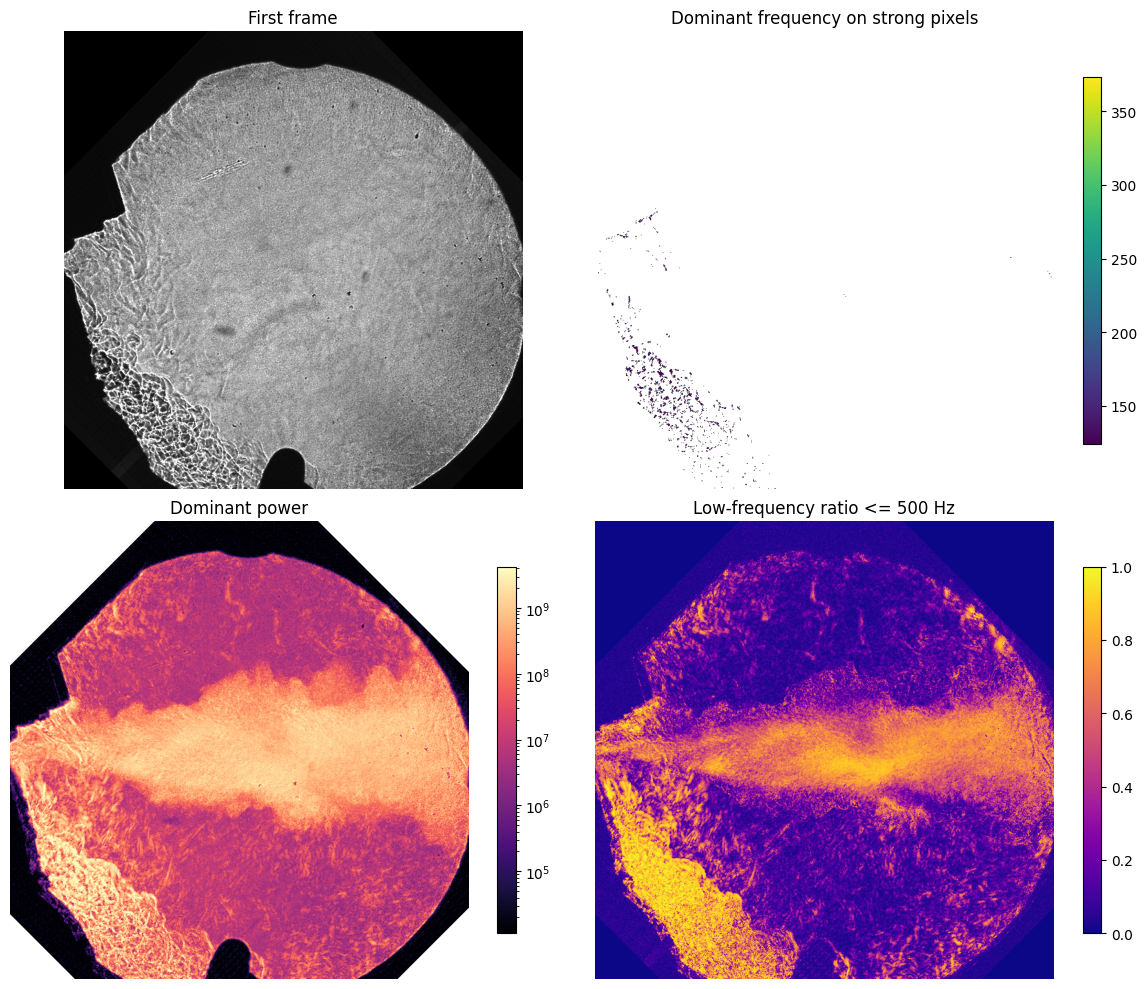

In [260]:
positive_power = dominant_power_map[dominant_power_map > 0]
log_vmin = np.percentile(positive_power, 5) if positive_power.size else 1.0
log_vmax = np.percentile(positive_power, 99.5) if positive_power.size else 10.0

masked_dominant_freq = np.ma.masked_where(~strong_mask, dominant_freq_map)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(frame0, vmin=np.percentile(frame0, 1), vmax=np.percentile(frame0, 99))
axes[0, 0].set_title("First frame")

im1 = axes[0, 1].imshow(masked_dominant_freq, cmap="viridis")
axes[0, 1].set_title("Dominant frequency on strong pixels")
plt.colorbar(im1, ax=axes[0, 1], shrink=0.8)

im2 = axes[1, 0].imshow(dominant_power_map, norm=LogNorm(vmin=log_vmin, vmax=log_vmax), cmap="magma")
axes[1, 0].set_title("Dominant power")
plt.colorbar(im2, ax=axes[1, 0], shrink=0.8)

im3 = axes[1, 1].imshow(low_ratio_map, vmin=0.0, vmax=1.0, cmap="plasma")
axes[1, 1].set_title(f"Low-frequency ratio <= {LOW_FREQ_CUTOFF_HZ:.0f} Hz")
plt.colorbar(im3, ax=axes[1, 1], shrink=0.8)

for ax in axes.ravel():
    ax.set_axis_off()

plt.tight_layout()
plt.show()

## 响应最强的几个像素

这一步看局部像素的频谱，确认全局峰值到底是真实像素行为，还是少数区域的偶然结果。

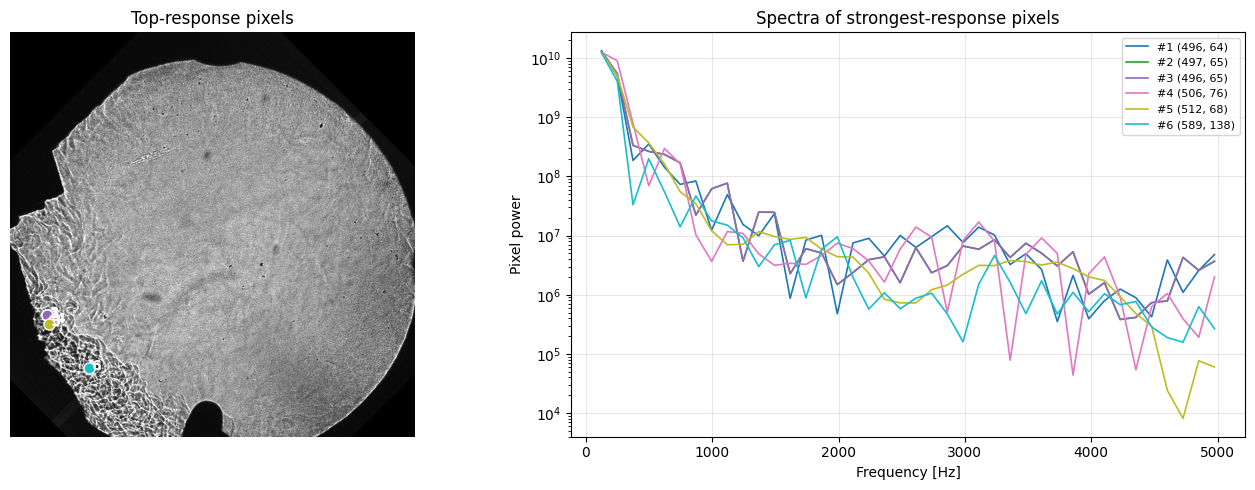

#1: (y=496, x=64), dominant freq = 124.38 Hz, dominant power = 1.334e+10
#2: (y=497, x=65), dominant freq = 124.38 Hz, dominant power = 1.294e+10
#3: (y=496, x=65), dominant freq = 124.38 Hz, dominant power = 1.294e+10
#4: (y=506, x=76), dominant freq = 124.38 Hz, dominant power = 1.250e+10
#5: (y=512, x=68), dominant freq = 124.38 Hz, dominant power = 1.247e+10
#6: (y=589, x=138), dominant freq = 124.38 Hz, dominant power = 1.231e+10


In [261]:
flat_power = dominant_power_map.ravel()
top_flat_idx = np.argpartition(flat_power, -TOP_PIXEL_COUNT)[-TOP_PIXEL_COUNT:]
top_flat_idx = top_flat_idx[np.argsort(flat_power[top_flat_idx])[::-1]]
top_coords = [(idx // width, idx % width) for idx in top_flat_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(frame0, vmin=np.percentile(frame0, 1), vmax=np.percentile(frame0, 99))
axes[0].set_title("Top-response pixels")

colors = plt.cm.tab10(np.linspace(0, 1, TOP_PIXEL_COUNT))
for i, ((y, x), color) in enumerate(zip(top_coords, colors), start=1):
    axes[0].plot(x, y, marker="o", ms=8, mec="white", mfc=color)
    axes[0].text(x + 4, y + 4, str(i), color="white", fontsize=10, weight="bold")

plot_mask = (freqs > 0) & (freqs <= MAX_PLOT_FREQ_HZ)
for i, ((y, x), color) in enumerate(zip(top_coords, colors), start=1):
    pixel_freqs, pixel_power = pixel_power_spectrum(
        video[:, y, x],
        fps=FPS,
        remove_temporal_mean=REMOVE_TEMPORAL_MEAN,
        apply_hann_window=APPLY_HANN_WINDOW,
    )
    axes[1].plot(pixel_freqs[plot_mask], pixel_power[plot_mask], color=color, lw=1.2, label=f"#{i} ({y}, {x})")

axes[1].set_yscale("log")
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("Pixel power")
axes[1].set_title("Spectra of strongest-response pixels")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper right", fontsize=8)

axes[0].set_axis_off()
plt.tight_layout()
plt.show()

for i, (y, x) in enumerate(top_coords, start=1):
    print(f"#{i}: (y={y}, x={x}), dominant freq = {dominant_freq_map[y, x]:.2f} Hz, dominant power = {dominant_power_map[y, x]:.3e}")

## 该怎么预处理：先给一个数据驱动建议

In [262]:
non_dc_mask = freqs > 0
low_mask = (freqs > 0) & (freqs <= LOW_FREQ_CUTOFF_HZ)

total_non_dc_power = mean_power[non_dc_mask].sum()
low_band_fraction = mean_power[low_mask].sum() / total_non_dc_power if total_non_dc_power > 0 else np.nan
top_peak_idx = peak_indices[0]
top_peak_freq = freqs[top_peak_idx]
top_peak_fraction = mean_power[top_peak_idx] / total_non_dc_power if total_non_dc_power > 0 else np.nan
median_strong_low_ratio = np.median(low_ratio_map[strong_mask]) if np.any(strong_mask) else np.nan
median_strong_freq = np.median(dominant_freq_map[strong_mask]) if np.any(strong_mask) else np.nan

print(f"Low-band power fraction: {low_band_fraction * 100:.2f}%")
print(f"Top global peak: {top_peak_freq:.2f} Hz")
print(f"Top-peak fraction of non-DC power: {top_peak_fraction * 100:.2f}%")
print(f"Median dominant freq on strong pixels: {median_strong_freq:.2f} Hz")
print(f"Median low-band ratio on strong pixels: {median_strong_low_ratio * 100:.2f}%")

recommendations = []

if low_band_fraction > 0.50 or median_strong_low_ratio > 0.70:
    recommendations.append(
        f"低频成分很重，先试逐像素 temporal mean subtraction，或者 {PREVIEW_HIGH_PASS_HZ:.0f} Hz 左右的时间高通。"
    )

if top_peak_freq > LOW_FREQ_CUTOFF_HZ and top_peak_fraction > 0.05:
    recommendations.append(
        f"存在较明显窄带峰值 {top_peak_freq:.2f} Hz，可以试一个以它为中心的小带阻 / notch。"
    )

if strong_mask.mean() < 0.05:
    recommendations.append("高响应像素只占很小区域，建议先做 ROI / mask，再做时间滤波。")

if not recommendations:
    recommendations.append("没有看到单一非常强的固定干扰峰，优先试背景扣除、归一化，和轻量高通，而不是很激进的 notch。")

print("\nSuggested preprocessing:")
for i, item in enumerate(recommendations, start=1):
    print(f"{i}. {item}")

Low-band power fraction: 57.67%
Top global peak: 124.38 Hz
Top-peak fraction of non-DC power: 33.14%
Median dominant freq on strong pixels: 124.38 Hz
Median low-band ratio on strong pixels: 94.47%

Suggested preprocessing:
1. 低频成分很重，先试逐像素 temporal mean subtraction，或者 8000 Hz 左右的时间高通。
2. 高响应像素只占很小区域，建议先做 ROI / mask，再做时间滤波。


## 试一个简单预处理：Butterworth 时间高通预览

这里用的是低阶 Butterworth 高通 + `sosfiltfilt` 零相位滤波。它比频域硬切平滑很多，比较适合先直接看效果。

In [263]:
if PREVIEW_FILTER_MODE == "highpass":
    filtered_video = temporal_high_pass_butterworth(
        video,
        fps=FPS,
        cutoff_hz=PREVIEW_HIGH_PASS_HZ,
        order=HIGH_PASS_FILTER_ORDER,
        chunk_pixels=CHUNK_PIXELS,
    )
    preview_filter_label = f"Butterworth HPF, {PREVIEW_HIGH_PASS_HZ:.0f} Hz, order={HIGH_PASS_FILTER_ORDER}"
elif PREVIEW_FILTER_MODE == "lowpass":
    filtered_video = temporal_low_pass_butterworth(
        video,
        fps=FPS,
        cutoff_hz=PREVIEW_LOW_PASS_HZ,
        order=LOW_PASS_FILTER_ORDER,
        chunk_pixels=CHUNK_PIXELS,
    )
    preview_filter_label = f"Butterworth LPF, {PREVIEW_LOW_PASS_HZ:.0f} Hz, order={LOW_PASS_FILTER_ORDER}"
elif PREVIEW_FILTER_MODE == "bandpass":
    filtered_video = temporal_band_pass_butterworth(
        video,
        fps=FPS,
        low_cut_hz=PREVIEW_LOW_PASS_HZ,
        high_cut_hz=PREVIEW_HIGH_PASS_HZ,
        order=HIGH_PASS_FILTER_ORDER,
        chunk_pixels=CHUNK_PIXELS,
    )
    preview_filter_label = (
        f"Butterworth BPF, {PREVIEW_LOW_PASS_HZ:.0f}-{PREVIEW_HIGH_PASS_HZ:.0f} Hz, "
        f"order={HIGH_PASS_FILTER_ORDER}"
    )
elif PREVIEW_FILTER_MODE == "bandstop":
    filtered_video = temporal_band_stop_butterworth(
        video,
        fps=FPS,
        low_cut_hz=PREVIEW_LOW_PASS_HZ,
        high_cut_hz=PREVIEW_HIGH_PASS_HZ,
        order=HIGH_PASS_FILTER_ORDER,
        chunk_pixels=CHUNK_PIXELS,
    )
    preview_filter_label = (
        f"Butterworth BSF, {PREVIEW_LOW_PASS_HZ:.0f}-{PREVIEW_HIGH_PASS_HZ:.0f} Hz, "
        f"order={HIGH_PASS_FILTER_ORDER}"
    )
else:
    raise ValueError(f"Unsupported PREVIEW_FILTER_MODE: {PREVIEW_FILTER_MODE}")


In [ ]:
from OSCC_postprocessing.utils.scaling import *
from OSCC_postprocessing.playback.video_playback import *
# play_video_cv2(min_max_scale(np.abs(filtered_video)), intv=17)
play_videos_side_by_side((video/4096.0, robust_scale(np.abs(filtered_video), q_min=50, q_max=99.9)), intv=50)

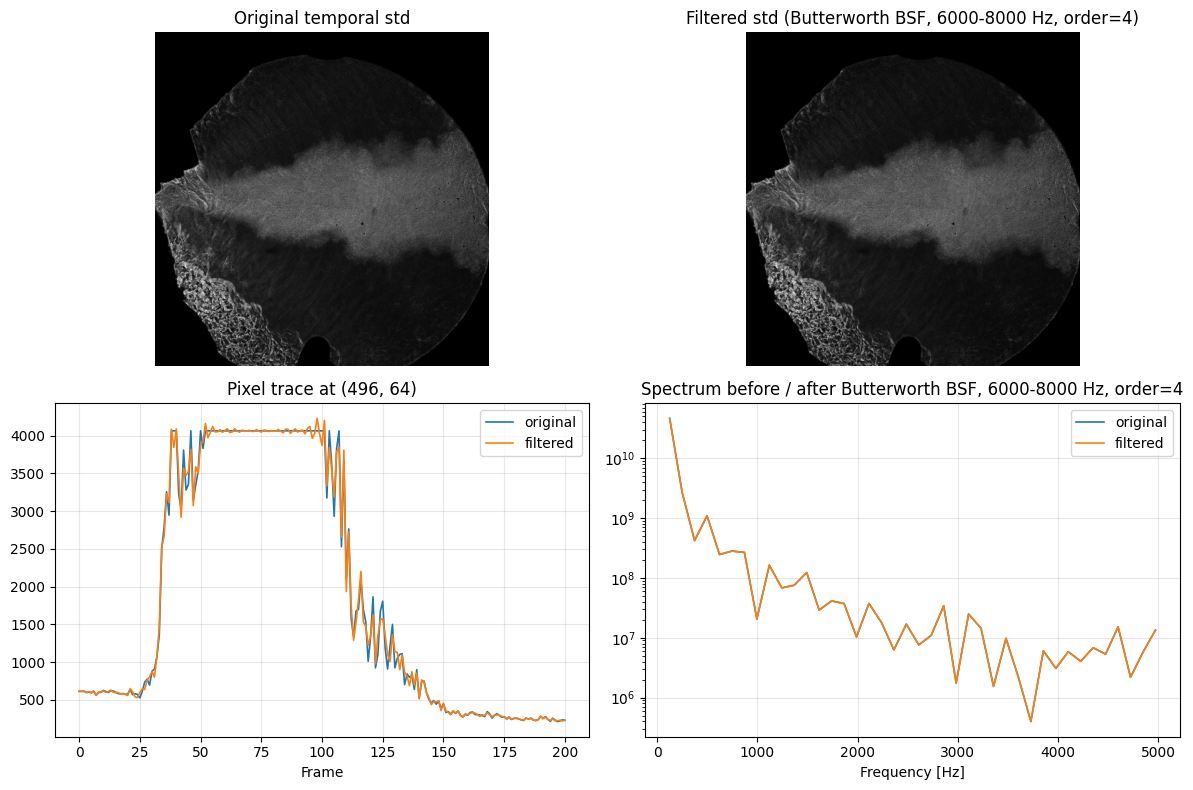

In [ ]:
filtered_std = filtered_video.std(axis=0)
best_y, best_x = top_coords[0]
orig_trace = video[:, best_y, best_x]
filt_trace = filtered_video[:, best_y, best_x]

orig_freqs, orig_power = pixel_power_spectrum(orig_trace, FPS, remove_temporal_mean=False, apply_hann_window=False)
filt_freqs, filt_power = pixel_power_spectrum(filt_trace, FPS, remove_temporal_mean=False, apply_hann_window=False)
plot_mask = (orig_freqs > 0) & (orig_freqs <= MAX_PLOT_FREQ_HZ)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].imshow(std_frame)
axes[0, 0].set_title("Original temporal std")
axes[0, 1].imshow(filtered_std)
axes[0, 1].set_title(f"Filtered std ({preview_filter_label})")

axes[1, 0].plot(orig_trace, label="original", lw=1.2)
axes[1, 0].plot(filt_trace, label="filtered", lw=1.2)
axes[1, 0].set_title(f"Pixel trace at ({best_y}, {best_x})")
axes[1, 0].set_xlabel("Frame")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(orig_freqs[plot_mask], orig_power[plot_mask], label="original", lw=1.2)
axes[1, 1].plot(filt_freqs[plot_mask], filt_power[plot_mask], label="filtered", lw=1.2)
axes[1, 1].set_yscale("log")
axes[1, 1].set_title(f"Spectrum before / after {preview_filter_label}")
axes[1, 1].set_xlabel("Frequency [Hz]")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

for ax in axes[0]:
    ax.set_axis_off()

plt.tight_layout()
plt.show()


## 下一步怎么用这个结果

如果你跑完以后看到：

- 大部分能量都在很低频：优先做逐像素去均值、去趋势，或者轻量时间高通
- 有一个非常尖的固定频率峰：优先做时间 notch
- 高频响应只集中在喷雾区域：先做 ROI / mask，再做滤波，避免背景噪声主导
- 不同区域主频差异很大：不要全局只用一种很激进的滤波，先从保守预处理开始

如果后面你想继续，我们可以直接在这个 notebook 上再加：

- 更稳的 per-pixel detrend
- 指定频率的 notch filter
- 按 ROI 统计平均频谱
- 把预处理结果直接接进你现在的 Mie pipeline